Lab 2 

DS 6021

Ciarra Barnett

In [63]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import statsmodels.formula.api as smf

In [64]:
penguins = pd.read_csv("data/penguins.csv")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Part 1 

In [65]:
penguins_clean = penguins.dropna(
    subset=[
        "body_mass_g",
        "flipper_length_mm",
        "bill_depth_mm",
        "bill_length_mm"
    ]
)

In [66]:
x = penguins_clean ["bill_depth_mm"]
y = penguins_clean ["body_mass_g"]
beta_1 = (( x-x.mean()) * (y-y.mean())).sum() / ((x-x.mean()) ** 2).sum()
beta_0 = y.mean() - beta_1 * x.mean()
y_hat = beta_0 + beta_1 * x

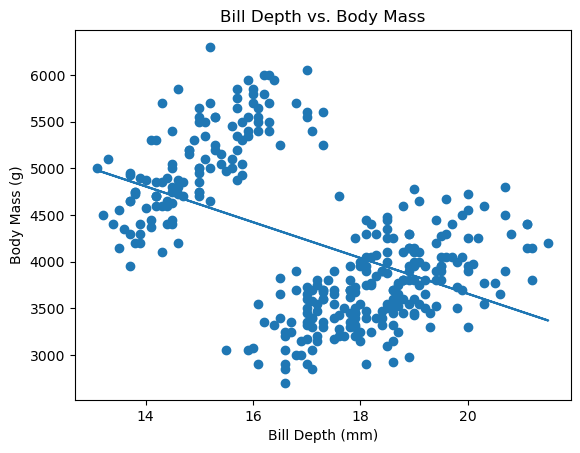

In [67]:
plt.scatter(x,y)
plt.plot(x, y_hat)

plt.xlabel ("Bill Depth (mm)")
plt.ylabel ("Body Mass (g)")
plt.title ("Bill Depth vs. Body Mass")

plt.show()

## 1a 
This scatterplot graph shows a negative relationship between bill depth and body mass because it the regression line is going downward. The relationship is moderate based on the data. I would have expected a positive relationship because it makes sense that penguins with deeper bills would have more body mass. 

In [68]:
print ("beta_0:", beta_0)
print ("beta_1:",beta_1)

beta_0: 7488.652400935164
beta_1: -191.64279133263315


## 1b 
The estimated regression equation is body mass = 7488.65 - 191.64 bill depth. The slope means for every 1mm increase in bill depth the body mass decreases by about 191.64 body mass grams. 


## 1c


In [69]:
residuals = y -y_hat

n = len(y)
RSE = np.sqrt((residuals ** 2). sum() / (n-2))
r =x.corr(y)
R_squared = r ** 2 
print("RSE:", RSE)
print("Correlation:" , r)
print("R-squared:", R_squared)


RSE: 708.0771775901097
Correlation: -0.47191562118606645
R-squared: 0.22270435351943096


The RSE is about 708.08 grams, which means the models predictions are 708.08 grams. The correlatoin is -0.472 which shows a negalive relationship between body mass and bill depth. R-squared is 0.223 which means 22.3% pf the variations of body mass, This means the bill depth alone is what was predicted. 

Part 2 

In [70]:
import statsmodels.api as sm
x = penguins_clean ["bill_depth_mm"]
y = penguins_clean ["body_mass_g"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        23:10:13   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340      0.000    6829.290    8148.014
bill_depth_mm  -191.6428     19.417     -9.870      0.000    -229.835    -153.450
==============================================================================
Omnibus:                        8.491   Durbin-Watson:                   2.338
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                6.653
Skew:                           0.242   Prob(JB):                       0.0359
Kurtosis:                       2.518   Cond. No.                         152.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2a

Standard error os 19.417, t-statistic = -9.870 and p value < 0.001. H0: Beta1 = 0, meaning there is no linear relationship 
Ha: beta1= not = 0, this means there is a linear relatiionship bewteen body mass grams and bill depth. 


## 2b

The R-squared value is 0.223, meaning bill depth explains about 22.3% of the variation in body mass.The p-value for the slope is less than 0.001, which means there is strong evidence that bill depth and body mass have a statistically significant relationship. These results are consistent because bill depth has a significant relationship with body mass, but bill depth alone only explains 22.3% of the variation in body mass. Other variables may also help explain body mass.

## 2c 

# AI assistance: ChatGPT (OpenAI) and Claude Code was used to help debug the bootstrap loop and confidence interval code.


In [71]:
B = 10000

beta0_boot = []
beta1_boot = []

for i in range(B):
    sample = penguins_clean.sample(
        n=len(penguins_clean),
        replace=True
    )

    x_boot = sample["bill_depth_mm"]
    y_boot = sample["body_mass_g"]

    beta1 = ((x_boot - x_boot.mean()) * 
             (y_boot - y_boot.mean())).sum() / ((x_boot - x_boot.mean()) ** 2).sum()

    beta0 = y_boot.mean() - beta1 * x_boot.mean()

    beta0_boot.append(beta0)
    beta1_boot.append(beta1) 
    beta0_ci = np.percentile(beta0_boot, [2.5, 97.5])
beta1_ci = np.percentile(beta1_boot, [2.5, 97.5])

print("Bootstrap 95% CI for beta0:", beta0_ci)
print("Bootstrap 95% CI for beta1:", beta1_ci)

Bootstrap 95% CI for beta0: [6963.21392413 8052.92569908]
Bootstrap 95% CI for beta1: [-223.33777997 -162.22165305]


In [72]:
model.conf_int()

,0,1
const,6829.290428,8148.014374
bill_depth_mm,-229.835335,-153.450247


The formula based confidence interval relies on assumptions about the distribution of the regression errors, including  normality. The bootstrap does not require the same normality assumption because it estimates uncertainty by continously resampling the observed data.

In [73]:
results = []

for B in [100, 1000, 10000]:
    for run in range(1, 11):
        
        beta0_ci, beta1_ci = bootstrap_ci(penguins_clean, B)
        
        results.append({
            "B": B,
            "Run": run,
            "beta0_lower": beta0_ci[0],
            "beta0_upper": beta0_ci[1],
            "beta1_lower": beta1_ci[0],
            "beta1_upper": beta1_ci[1]
        })

results_df = pd.DataFrame(results)

results_df

,B,Run,beta0_lower,beta0_upper,beta1_lower,beta1_upper
0,100,1,6899.217792,8028.760689,-225.374761,-160.160339
1,100,2,6835.226385,7929.320072,-216.154135,-153.519143
2,100,3,7054.601232,8049.908701,-221.317518,-167.629869
3,100,4,6996.356197,8135.024113,-231.269585,-165.403237
4,100,5,6988.007116,8023.308117,-223.248803,-164.670308
5,100,6,6902.876831,8119.265013,-228.740156,-158.824772
6,100,7,6962.014612,8121.097697,-228.111708,-164.276086
7,100,8,7073.564826,7987.580015,-218.973164,-169.071607
8,100,9,6969.251309,7969.332629,-217.963546,-162.597461
9,100,10,7051.741597,8035.101891,-220.967851,-167.541108


## 2c (a & d)

The bootstrap gave narrower confidence intervals than statsmodels. When B was small (100), the results changed a lot between tests. When B increased to 1,000 and 10,000, the results became much more stable. This shows that a larger B gives more reliable results.

Part 3 

In [74]:
fitted_bill = model.fittedvalues
residuals_bill = model.resid

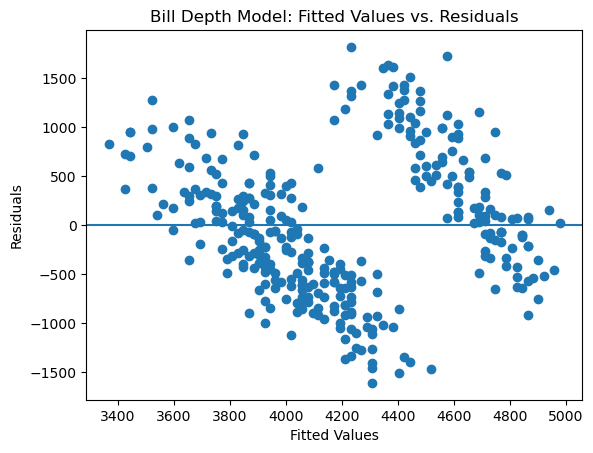

In [75]:
plt.scatter(fitted_bill, residuals_bill)

plt.axhline(y=0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Bill Depth Model: Fitted Values vs. Residuals")

plt.show()

In [76]:
penguins_resid = penguins.dropna(
    subset=["bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]
)

In [77]:
x_flipper = penguins_resid["flipper_length_mm"]
y_flipper = penguins_resid["body_mass_g"]

X_flipper = sm.add_constant(x_flipper)

model_flipper = sm.OLS(y_flipper, X_flipper).fit()

fitted_flipper = model_flipper.fittedvalues
residuals_flipper = model_flipper.resid

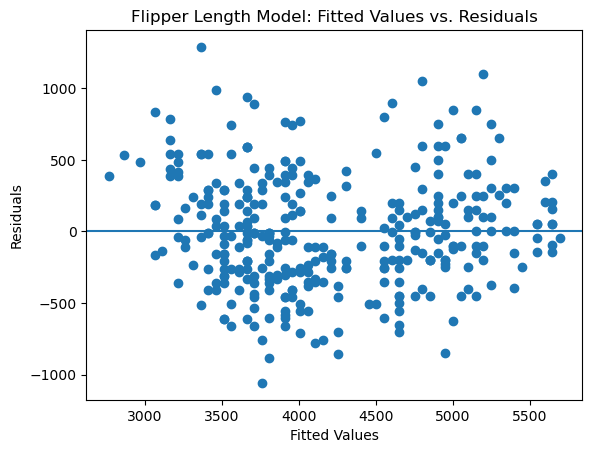

In [78]:
plt.scatter(fitted_flipper, residuals_flipper)

plt.axhline(y=0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Flipper Length Model: Fitted Values vs. Residuals")

plt.show()
 
 

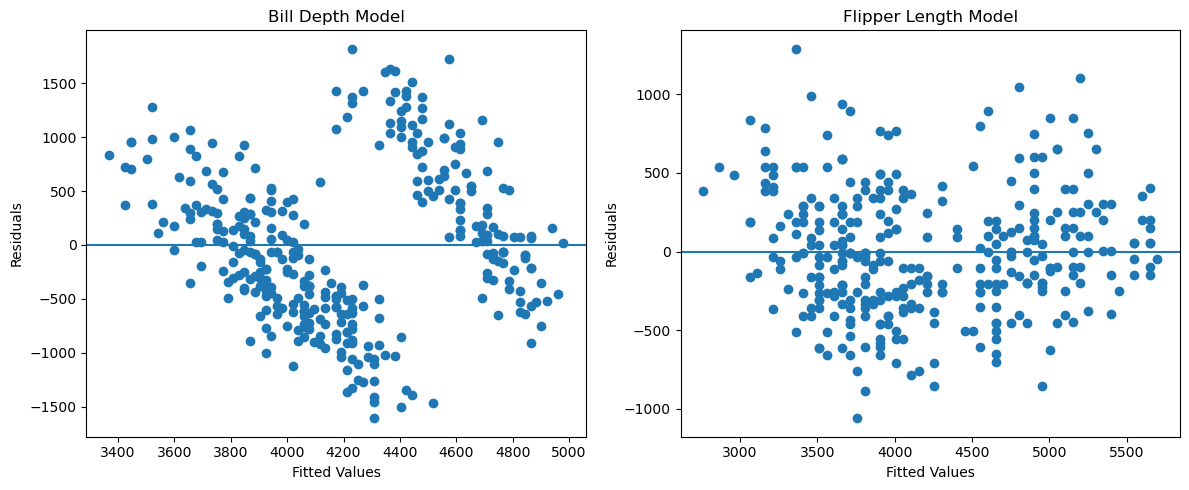

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted_bill, residuals_bill)
axes[0].axhline(y=0)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Bill Depth Model")

axes[1].scatter(fitted_flipper, residuals_flipper)
axes[1].axhline(y=0)
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Flipper Length Model")

plt.tight_layout()
plt.show()

## 3a

The bill depth model has a clear pattern in the residuals instead of being randomly scattered around zero. This suggests that bill depth alone does not predict body mass very well. The flipper length model has residuals that are more evenly scattered around zero. This suggests that flipper length does a better job of predicting body mass than bill depth. 

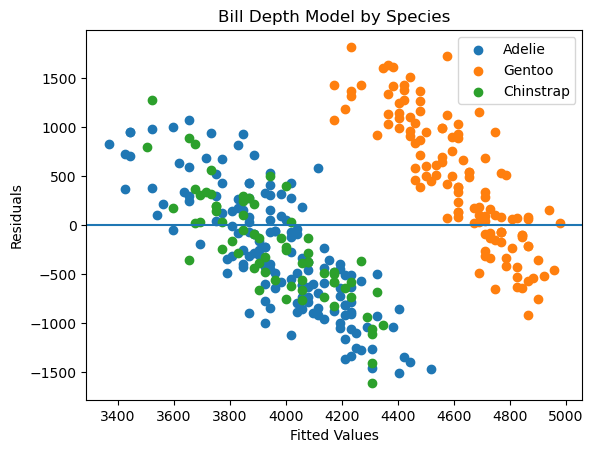

In [80]:
for species in penguins_resid["species"].unique():
    mask = penguins_resid["species"] == species

    plt.scatter(
        fitted_bill[mask],
        residuals_bill[mask],
        label=species
    )

plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Bill Depth Model by Species")
plt.legend()
plt.show()

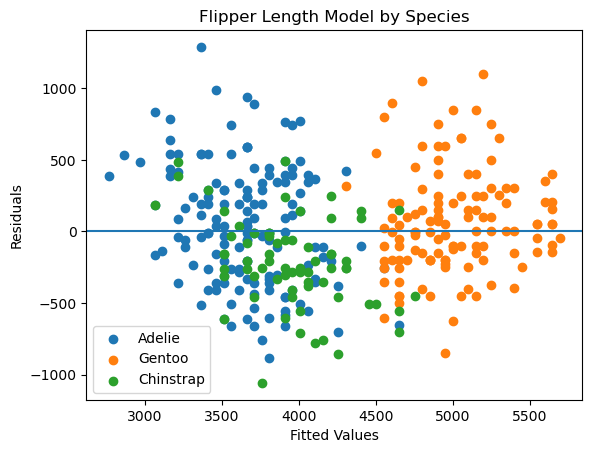

In [81]:
for species in penguins_resid["species"].unique():
    mask = penguins_resid["species"] == species

    plt.scatter(
        fitted_flipper[mask],
        residuals_flipper[mask],
        label=species
    )

plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Flipper Length Model by Species")
plt.legend()
plt.show()

## 3b 

When the residuals are colored by species the penguins are forming different groups. This shows the species are affecting the body mass and predictors. The bill  depth model shows a stronger pattern between the species the flipper length model has residuals that are more evenly scattered around zero. 

## 3c 


In [82]:
overall_corr = penguins_clean["bill_depth_mm"].corr(
    penguins_clean["body_mass_g"]
)

print("All penguins:", overall_corr)

All penguins: -0.47191562118606645


In [83]:
species_corr = (
    penguins_clean
    .groupby("species")[["bill_depth_mm", "body_mass_g"]]
    .corr()
)

Combined, penguins show a moderate negative correlation -0.472 between bill depth and body mass. Separately, each individual species shows a positive relationship between these two traits. This flip occurs because different species have different average body sizes and bill shapes. 

In [84]:
adelie = penguins_clean[penguins_clean["species"] == "Adelie"]

x_adelie = adelie["bill_depth_mm"]
y_adelie = adelie["body_mass_g"]

X_adelie = sm.add_constant(x_adelie)

model_adelie = sm.OLS(y_adelie, X_adelie).fit()

model_adelie.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     74.03
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           9.94e-15
Time:                        23:10:52   Log-Likelihood:                -1108.6
No. Observations:                 151   AIC:                             2221.
Df Residuals:                     149   BIC:                             2227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -283.2787    464.033     -0.610      0.542   -1200.214     633.657
bill_depth_mm   217.1516     25.238      8.604      0.000     167.281     267.022
==============================================================================
Omnibus:                        3.569   Durbin-Watson:                   2.280
Prob(Omnibus):                  0.168   Jarque-Bera (JB):                3.451
Skew:                           0.370   Prob(JB):                        0.178
Kurtosis:                       2.953   Cond. No.                         280.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

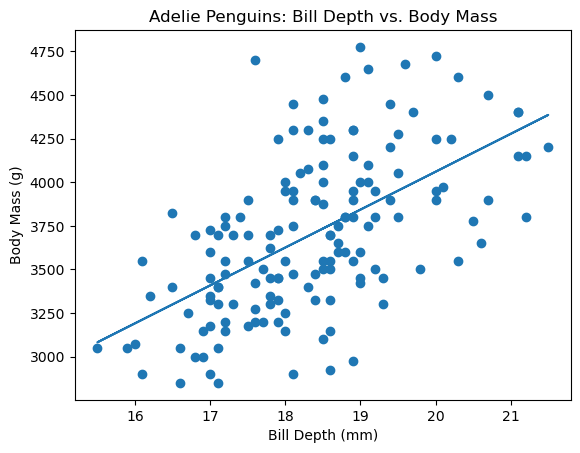

In [85]:
plt.scatter(x_adelie, y_adelie)

plt.plot(x_adelie, model_adelie.fittedvalues)

plt.xlabel("Bill Depth (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Adelie Penguins: Bill Depth vs. Body Mass")

plt.show()

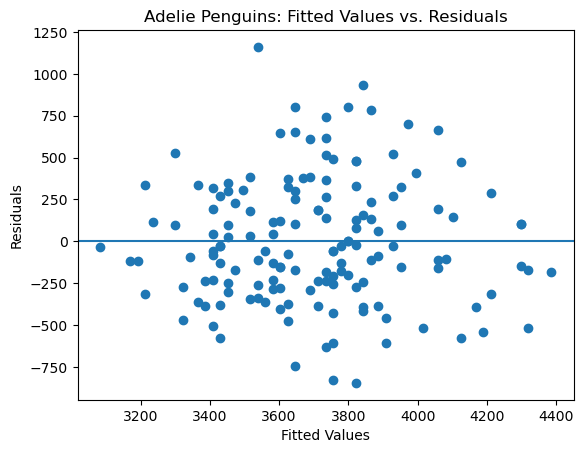

In [86]:
fitted_adelie = model_adelie.fittedvalues
residuals_adelie = model_adelie.resid

plt.scatter(fitted_adelie, residuals_adelie)

plt.axhline(y=0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Adelie Penguins: Fitted Values vs. Residuals")

plt.show()

In [87]:
print("Intercept:", model_adelie.params["const"])
print("Slope:", model_adelie.params["bill_depth_mm"])
print("R-squared:", model_adelie.rsquared)

Intercept: -283.27873116165307
Slope: 217.15160394376414
R-squared: 0.3319351878122039


## 3d

For Adelie penguins, bill depth and body mass have a positive relationship. As bill depth increases, body mass generally increases.The fitted vs. residuals plot shows the errors around the regression model. The Adelie only model shows that bill depth is more useful when looking at one species separately.

This is different from the model using all penguins, which showed a negative relationship. This happens because combining different species changes the overall relationship. Looking only at Adelies shows the positive relationship within the species.

Part 4 

### 4a
R^2 can only stya the same or increase when predictors are added. Adjusted R^2 considers whether the new predictors actually improve the model. Adjusted R^2 is better for comparing models with different numbers of predictors.

In [88]:
model_df = penguins[
    ['body_mass_g', 'flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']
].dropna() 
import statsmodels.formula.api as smf

model1 = smf.ols(
    'body_mass_g ~ flipper_length_mm',
    data=model_df
).fit()

model2 = smf.ols(
    'body_mass_g ~ flipper_length_mm + bill_depth_mm',
    data=model_df
).fit()

model3 = smf.ols(
    'body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm',
    data=model_df
).fit()

In [89]:

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'R^2': [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared
    ],
    'Adjusted R^2': [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj
    ],
    'RSE': [
        np.sqrt(model1.mse_resid),
        np.sqrt(model2.mse_resid),
        np.sqrt(model3.mse_resid)
    ],
    'F-statistic': [
        model1.fvalue,
        model2.fvalue,
        model3.fvalue
    ]
})

results

,Model,R^2,Adjusted R^2,RSE,F-statistic
0,Model 1,0.758993,0.758284,394.278178,1070.744592
1,Model 2,0.761040,0.759630,393.178380,539.823944
2,Model 3,0.761470,0.759353,393.404797,359.671804


###  4b

I would choose the model with the highest adjusted R^2 and lowest RSE. This model explains more variation in body mass while also accounting for the number of predictors used. Model 2 

In [90]:
model2.params

Intercept           -6541.907498
flipper_length_mm      51.541445
bill_depth_mm          22.634138
dtype: float64

# 4c 


Bill depth became positive when flipper length was included in the model.This means penguins with deeper bills (22.63g) tend to have higher body mass when flipper length is kept the same. The relationship changed because the first model did not include flipper length.

## 4d 

H0: The predictors do not affect body mass. HA: At least one predictor affects body mass. Since the p-value is less than 0.05, I reject H0. The model is significant.


Part 5  
# AI assistance: ChatGPT (OpenAI) and Claude Code was used to help debug model variable names, residual calculations, and the log model code.

In [91]:
planets = pd.read_csv("data/PlanetsData.csv")

planets.head()

,planet,distance,diameter,revolution,position
0,Mercury,36,3030,88,1
1,Venus,67,7520,225,2
2,Earth,93,7926,365,3
3,Mars,142,4217,687,4
4,Jupiter,484,88838,4332,5


In [92]:
print(planets.columns)

Index(['planet', 'distance', 'diameter', 'revolution', 'position'], dtype='object')


In [93]:
planet_model = smf.ols(
    "revolution ~ distance",
    data=planets
).fit()

planet_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             revolution   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           4.59e-07
Time:                        23:10:52   Log-Likelihood:                -88.599
No. Observations:                   9   AIC:                             181.2
Df Residuals:                       7   BIC:                             181.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4578.7935   2287.376     -2.002      0.085   -9987.578     829.991
distance      24.0957      1.364     17.666      0.000      20.870      27.321
==============================================================================
Omnibus:                        0.877   Durbin-Watson:                   0.788
Prob(Omnibus):                  0.645   Jarque-Bera (JB):                0.615
Skew:                          -0.214   Prob(JB):                        0.735
Kurtosis:                       1.793   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [94]:
planet_model.rsquared


np.float64(0.9780632018272492)

In [95]:
planets["predicted"] = planet_model.fittedvalues

planets[
    ["planet", "revolution", "predicted"]
]

,planet,revolution,predicted
0,Mercury,88,-3711.348645
1,Venus,225,-2964.382280
2,Earth,365,-2337.894361
3,Mars,687,-1157.205590
4,Jupiter,4332,7083.520113
5,Saturn,10760,16794.082858
6,Uranus,30684,37950.097969
7,Neptune,60188,62672.275081
8,Pluto,90467,83466.854854


# 5a



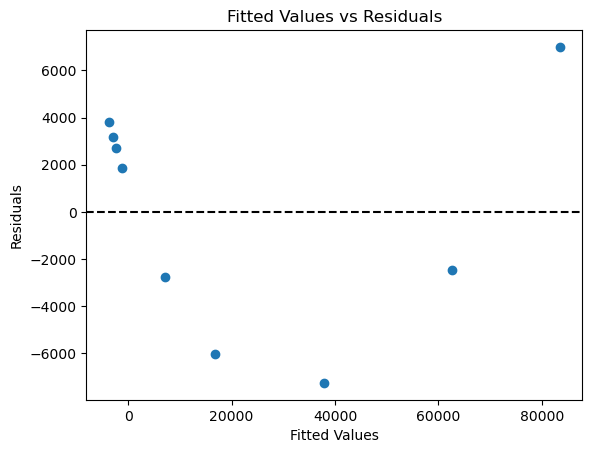

In [96]:
plt.scatter(
    planet_model.fittedvalues,
    planet_model.resid
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs Residuals")

plt.show()

In [97]:
planets["fitted"] = planet_model.fittedvalues
planets["residuals"] = planet_model.resid

planets[
    ["planet", "fitted", "residuals"]
]

,planet,fitted,residuals
0,Mercury,-3711.348645,3799.348645
1,Venus,-2964.382280,3189.382280
2,Earth,-2337.894361,2702.894361
3,Mars,-1157.205590,1844.205590
4,Jupiter,7083.520113,-2751.520113
5,Saturn,16794.082858,-6034.082858
6,Uranus,37950.097969,-7266.097969
7,Neptune,62672.275081,-2484.275081
8,Pluto,83466.854854,7000.145146


# 5b 

The residuals show a pattern instead of being randomly spread around zero. Pluto has the largest positive residual, and Uranus has the largest negative residual. This means the linear model is not a good fit 




In [98]:

planets["log_distance"] = np.log(planets["distance"])
planets["log_revolution"] = np.log(planets["revolution"])

log_model = smf.ols(
    "log_revolution ~ log_distance",
    data=planets
).fit()

log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         log_revolution   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        23:10:52   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.9031      0.007   -122.147      0.000      -0.921      -0.886
log_distance     1.5013      0.001   1259.092      0.000       1.498       1.504
==============================================================================
Omnibus:                        4.152   Durbin-Watson:                   2.345
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                1.862
Skew:                           1.112   Prob(JB):                        0.394
Kurtosis:                       2.882   Cond. No.                         24.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

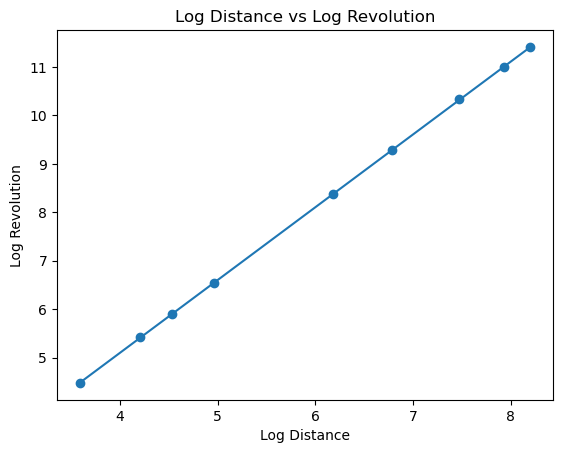

In [99]:
plt.scatter(
    planets["log_distance"],
    planets["log_revolution"]
)

plt.plot(
    planets["log_distance"],
    log_model.fittedvalues
)

plt.xlabel("Log Distance")
plt.ylabel("Log Revolution")
plt.title("Log Distance vs Log Revolution")

plt.show()

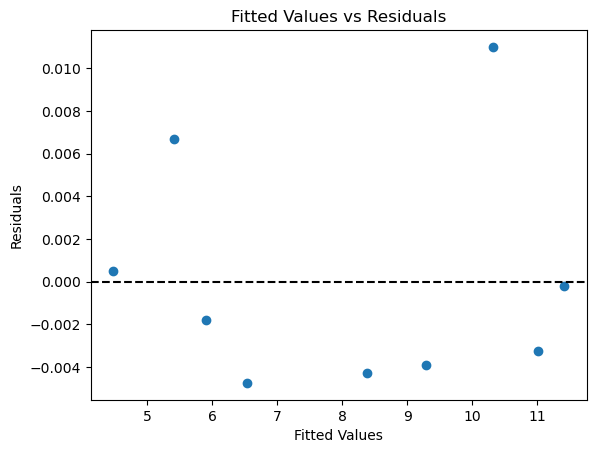

In [100]:
plt.scatter(log_model.fittedvalues, log_model.resid)
plt.axhline(y=0, color="black", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs Residuals")

plt.show()

In [101]:
print("R²:", log_model.rsquared)
print("Slope:", log_model.params["log_distance"])

R²: 0.9999955844871167
Slope: 1.5013054235713066


In [102]:
planets["log_fitted"] = log_model.fittedvalues
planets["fitted_revolution"] = np.exp(planets["log_fitted"])

planets[["planet", "revolution", "fitted_revolution"]]

,planet,revolution,fitted_revolution
0,Mercury,88,87.955672
1,Venus,225,223.498426
2,Earth,365,365.655904
3,Mars,687,690.272590
4,Jupiter,4332,4350.622150
5,Saturn,10760,10802.199220
6,Uranus,30684,30348.267640
7,Neptune,60188,60383.237531
8,Pluto,90467,90486.168764


## 5c (a,b,c,d)

The original model had an R^² of 0.978, but it gave negative predictions for the inner planets. The log model was much better, with an R^² of 1.000 and predictions close to the actual values. The slope was about 1.5 = 3/2 which supports revolution^2  distance^3. 

